## **Cloning Repository and Captions Generating**

In [1]:
!rm -rf /kaggle/working/cossacks_data

import os

if not os.path.exists("cossacks-lora"):
    !git clone https://github.com/Hannysia/cossacks-lora.git

%cd cossacks-lora

!python scripts/annotate_dataset.py

Cloning into 'cossacks-lora'...
remote: Enumerating objects: 104, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 104 (delta 0), reused 104 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (104/104), 29.04 MiB | 15.72 MiB/s, done.
/kaggle/working/cossacks-lora
Successfully loaded HF_TOKEN from Kaggle Secrets.
Fetching 48 files: 100%|████████████████████████| 48/48 [00:08<00:00,  5.92it/s]
Download complete: : 8.00MB [00:08, 1.13MB/s]                                   Dataset downloaded to /kaggle/working/cossacks_data
Using device: cpu

preprocessor_config.json: 100%|█████████████████| 287/287 [00:00<00:00, 909kB/s]
The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `us

## **Captions Quality Check**

Found 47 images. Displaying all pairs:

File: cossack_001.jpg
Caption: kzk style, a painting of a village with flowers and trees


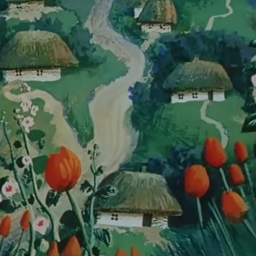

------------------------------------------------------------
File: cossack_002.jpg
Caption: kzk style, a cartoon character is sitting on a rock


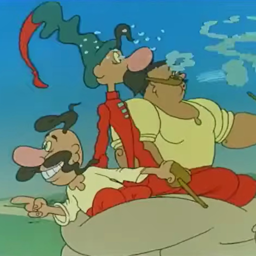

------------------------------------------------------------
File: cossack_003.jpg
Caption: kzk style, a painting of a street with buildings and a clock


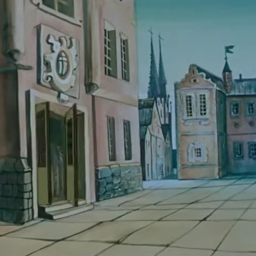

------------------------------------------------------------
File: cossack_004.jpg
Caption: kzk style, a cartoon character is being pulled by a woman


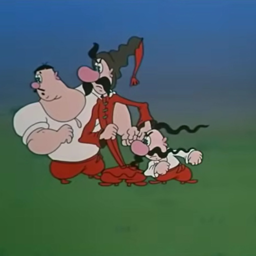

------------------------------------------------------------
File: cossack_005.jpg
Caption: kzk style, a cartoon character kissing a woman


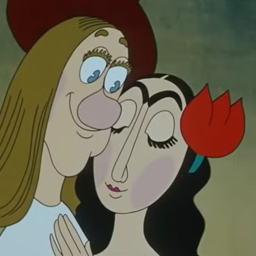

------------------------------------------------------------
File: cossack_006.jpg
Caption: kzk style, a cartoon character is standing in front of a mirror


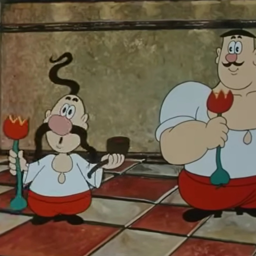

------------------------------------------------------------
File: cossack_007.jpg
Caption: kzk style, a cartoon character is doing a barbell


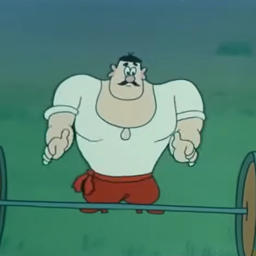

------------------------------------------------------------
File: cossack_008.jpg
Caption: kzk style, a rendering of a city with a large body of water


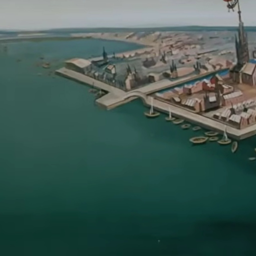

------------------------------------------------------------
File: cossack_009.jpg
Caption: kzk style, a cartoon boat with a group of people in it


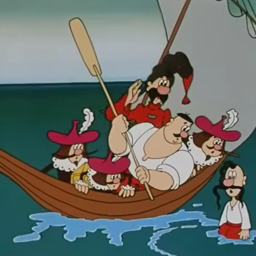

------------------------------------------------------------
File: cossack_010.jpg
Caption: kzk style, a painting of a field with red flowers


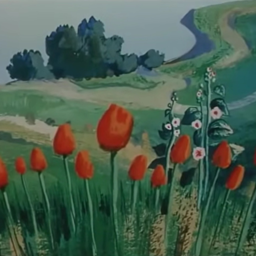

------------------------------------------------------------
File: cossack_011.jpg
Caption: kzk style, a cartoon scene of a mountain with sheeps


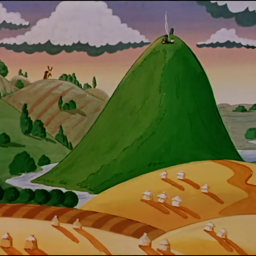

------------------------------------------------------------
File: cossack_012.jpg
Caption: kzk style, a cartoon of two men cooking food in a pot


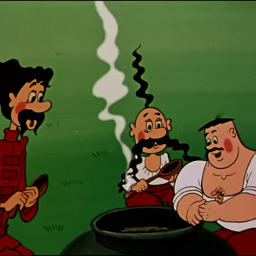

------------------------------------------------------------
File: cossack_013.jpg
Caption: kzk style, a cartoon character is standing on a hill


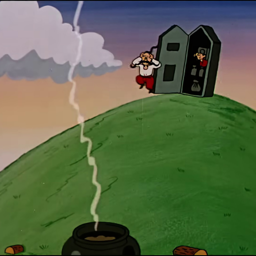

------------------------------------------------------------
File: cossack_014.jpg
Caption: kzk style, the flints in the flints cartoon


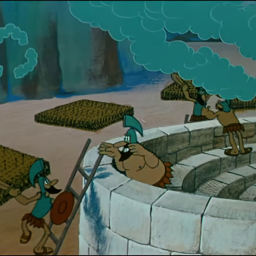

------------------------------------------------------------
File: cossack_015.jpg
Caption: kzk style, a cartoon character holding two bottles of beer


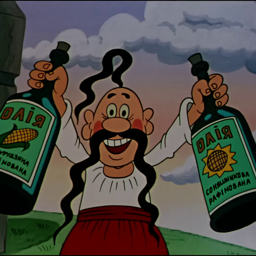

------------------------------------------------------------
File: cossack_016.jpg
Caption: kzk style, a cartoon character with a mustache and a mustache


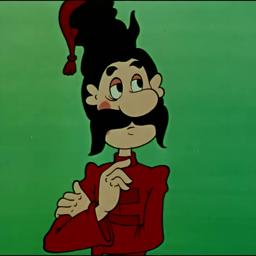

------------------------------------------------------------
File: cossack_017.jpg
Caption: kzk style, a cartoon character is looking at a map


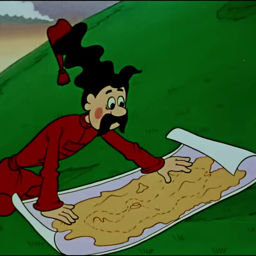

------------------------------------------------------------
File: cossack_018.jpg
Caption: kzk style, a cartoon character flying over a hill


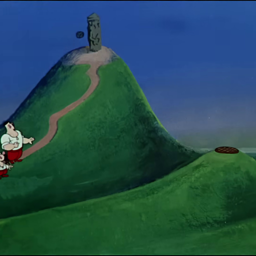

------------------------------------------------------------
File: cossack_019.jpg
Caption: kzk style, a cartoon scene with a man and a cow


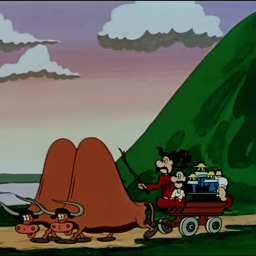

------------------------------------------------------------
File: cossack_020.jpg
Caption: kzk style, a cartoon character flying over a hill


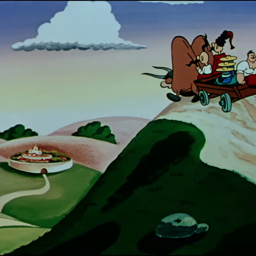

------------------------------------------------------------
File: cossack_021.jpg
Caption: kzk style, a cartoon character holding a bottle of wine


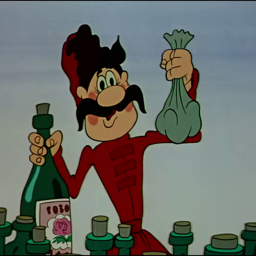

------------------------------------------------------------
File: cossack_022.jpg
Caption: kzk style, a cartoon character is playing with a dog


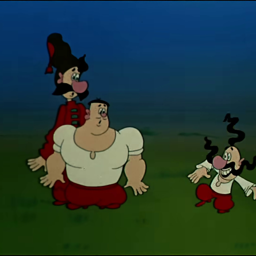

------------------------------------------------------------
File: cossack_023.jpg
Caption: kzk style, a man in the water with a large body


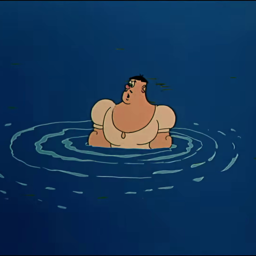

------------------------------------------------------------
File: cossack_024.jpg
Caption: kzk style, a cartoon scene of a man in a tent


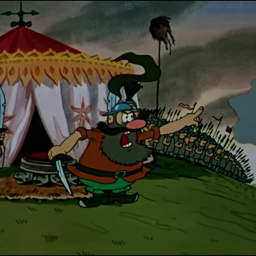

------------------------------------------------------------
File: cossack_025.jpg
Caption: kzk style, a cartoon character is being pulled by a man


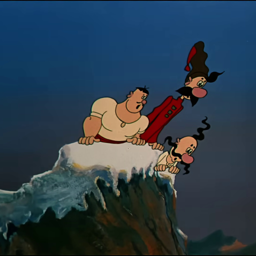

------------------------------------------------------------
File: cossack_026.jpg
Caption: kzk style, a cartoon picture of a castle with a castle in the background


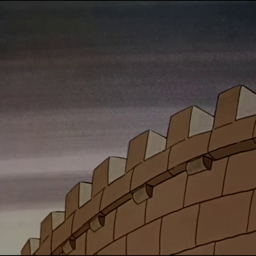

------------------------------------------------------------
File: cossack_027.jpg
Caption: kzk style, a cartoon scene of a man pushing a horse


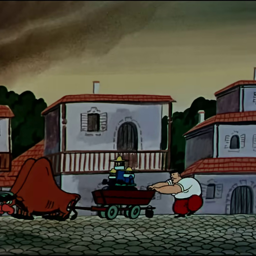

------------------------------------------------------------
File: cossack_028.jpg
Caption: kzk style, a cartoon picture of a train with a cannon


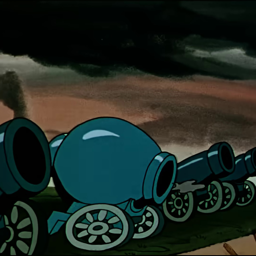

------------------------------------------------------------
File: cossack_029.jpg
Caption: kzk style, a cartoon scene with people in the middle of a circle


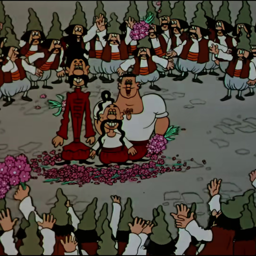

------------------------------------------------------------
File: cossack_030.jpg
Caption: kzk style, a cartoon scene with a group of people


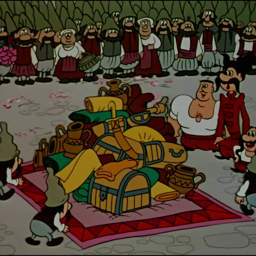

------------------------------------------------------------
File: cossack_031.jpg
Caption: kzk style, a cartoon scene with a bull and a man in the middle


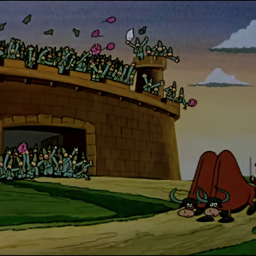

------------------------------------------------------------
File: cossack_032.jpg
Caption: kzk style, a cartoon picture of a desert with a mountain in the background


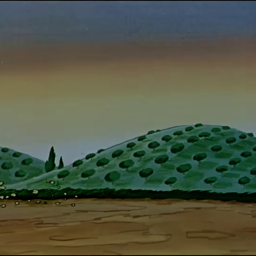

------------------------------------------------------------
File: cossack_033.jpg
Caption: kzk style, a cartoon scene of a man in a red cloak


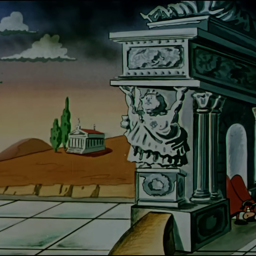

------------------------------------------------------------
File: cossack_034.jpg
Caption: kzk style, a cartoon character is holding a sword in front of a building


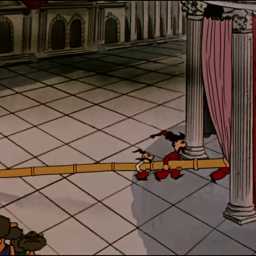

------------------------------------------------------------
File: cossack_035.jpg
Caption: kzk style, a cartoon picture of a building with a green roof


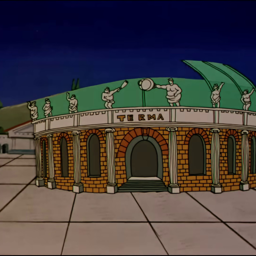

------------------------------------------------------------
File: cossack_036.jpg
Caption: kzk style, a cartoon scene of a man driving a car


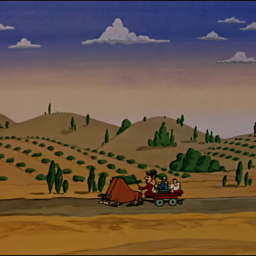

------------------------------------------------------------
File: cossack_037.jpg
Caption: kzk style, a cartoon scene with a castle on top of a hill


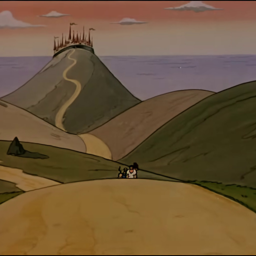

------------------------------------------------------------
File: cossack_038.jpg
Caption: kzk style, a cartoon of a woman in a red dress


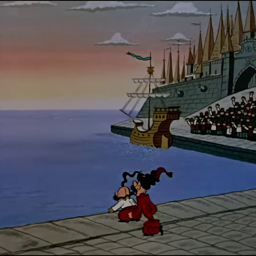

------------------------------------------------------------
File: cossack_039.jpg
Caption: kzk style, a cartoon scene with a man and woman in a castle


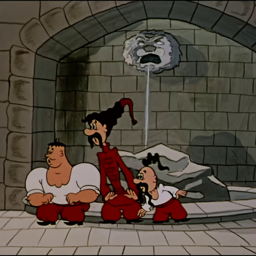

------------------------------------------------------------
File: cossack_040.jpg
Caption: kzk style, a cartoon street with buildings and a clock


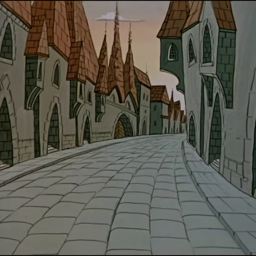

------------------------------------------------------------
File: cossack_041.jpg
Caption: kzk style, the road to the castle


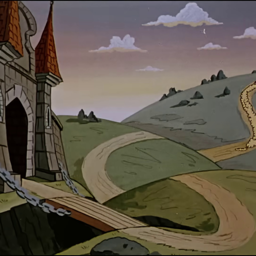

------------------------------------------------------------
File: cossack_042.jpg
Caption: kzk style, a cartoon scene with a man and a dog


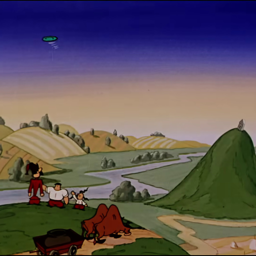

------------------------------------------------------------
File: cossack_043.jpg
Caption: kzk style, a cartoon character riding a bike with two other characters


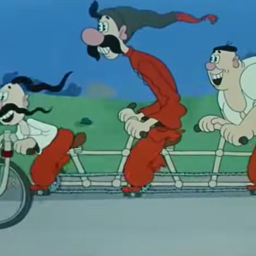

------------------------------------------------------------
File: cossack_044.jpg
Caption: kzk style, a painting of a street with buildings and a clock


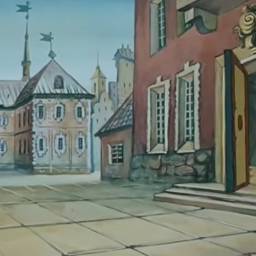

------------------------------------------------------------
File: cossack_045.jpg
Caption: kzk style, a cartoon character is standing in front of a sink


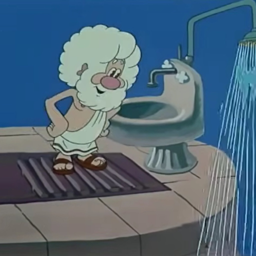

------------------------------------------------------------
File: cossack_046.jpg
Caption: kzk style, a cartoon character is standing on a hill


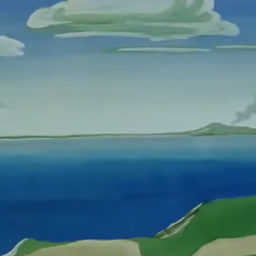

------------------------------------------------------------
File: cossack_047.jpg
Caption: kzk style, a cartoon of a mountain with windmills on top


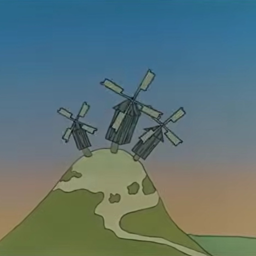

------------------------------------------------------------


In [2]:
from PIL import Image
from IPython.display import display

LOCAL_DIR = "/kaggle/working/cossacks_data"

def check_all_annotations():
    
    images = sorted([f for f in os.listdir(LOCAL_DIR) if f.lower().endswith(('.png', '.jpg'))])
    
    if not images:
        print("No images found!")
        return

    print(f"Found {len(images)} images. Displaying all pairs:\n")
    print("=" * 60)
    
    for img_name in images:
        img_path = os.path.join(LOCAL_DIR, img_name)
        txt_path = os.path.splitext(img_path)[0] + ".txt"
        
        caption = "❌ Annotation file not found!"
        if os.path.exists(txt_path):
            with open(txt_path, "r", encoding="utf-8") as f:
                caption = f.read()
        
        print(f"File: {img_name}")
        print(f"Caption: {caption}")
        
        img = Image.open(img_path)
        img.thumbnail((256, 256)) 
        display(img)
        
        print("-" * 60) 

if __name__ == "__main__":
    check_all_annotations()

## **Correcting Poor Captions**

In [ ]:
from huggingface_hub import HfApi, CommitOperationAdd, CommitOperationDelete

# --- FETCH HF TOKEN FROM KAGGLE SECRETS ---
try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    HF_TOKEN = user_secrets.get_secret("HF_TOKEN")
    print("Successfully loaded HF_TOKEN from Kaggle Secrets.")
except Exception as e:
    print(f"Error loading Kaggle Secrets: {e}")
    HF_TOKEN = None

# --- CONFIGURATION ---
HF_DATASET_REPO = "hannusia123123/cossacks-lora"
TO_DELETE_IDS = ["013", "018", "020", "034"]

# Updated captions
FIXES = {
    "cossack_002.txt": "kzk style, three cossacks sitting on a large sack, smoking pipes, blue sky",
    "cossack_003.txt": "kzk style, an empty cobblestone street in an old European town, historic buildings with spires, cartoon background",
    "cossack_004.txt": "kzk style, three cossacks standing together, looking angry with clenched fists, green field and blue sky with horizon line",
    "cossack_005.txt": "kzk style, close up of a young man with long hair and a young woman, cheeks touching", 
    "cossack_006.txt": "kzk style, short cossack and strong cossack, standing side by side, both holding red tulips, short cossack looks surprised, strong cossack looks dreamy, checkered floor",
    "cossack_007.txt": "kzk style, a strong muscular cossack standing over a barbell, green field background",
    "cossack_008.txt": "kzk style, aerial view of a harbor city, old european architecture, many small boats in the water, coastline and buildings",
    "cossack_009.txt": "kzk style, several cossacks and musketeers in a wooden boat on the water, one cossack standing in the water near the boat, one cossack holding a paddle",
    "cossack_010.txt": "kzk style, green field landscape, prominent red tulips and white mallows in the foreground, cartoon background",
    "cossack_011.txt": "kzk style, rural landscape, large green hill, haystacks in the foreground, river in the background, cartoon style",
    "cossack_012.txt": "kzk style, three cossacks cooking food in a large black cauldron, holding wooden spoons, steam rising, green background",
    "cossack_014.txt": "kzk style, ancient warriors in helmets near a circular stone tower, one warrior climbing a ladder, smoke and clouds, cartoon background",
    "cossack_015.txt": "kzk style, a short smiling cossack with a long mustache holding two large bottles of oil, green field and cloudy sky background",
    "cossack_016.txt": "kzk style, close up of a tall cossack in a red caftan and hat, holding a hand to his chin, thinking pose, green background",
    "cossack_017.txt": "kzk style, a tall cossack in red clothes leaning over a large map on the ground, green hill background",
    "cossack_019.txt": "kzk style, three cossacks on a wooden cart pulled by two large brown oxen, green hill and cloudy sky background",
    "cossack_021.txt": "kzk style, a tall cossack in red holding a green bottle of oil and a small bag, many bottle necks in the foreground, cartoon background",   
    "cossack_022.txt": "kzk style, three cossacks together on a green field, a tall cossack, a strong muscular cossack, and a short cossack dancing, cartoon background",
    "cossack_023.txt": "kzk style, a strong muscular cossack in the water, ripples on water surface around him, dark blue water background",
    "cossack_024.txt": "kzk style, an angry bearded commander in front of a tent, pointing with his finger, holding a dagger, army of soldiers in the background",
    "cossack_025.txt": "kzk style, three cossacks looking down from a snowy mountain ledge, dark blue night sky, surprised expressions",
    "cossack_026.txt": "kzk style, close up of a curved stone fortress wall with battlements, dark cloudy sky background",
    "cossack_027.txt": "kzk style, the kzk_tur character pushing a wooden cart with bottles from behind, oxen harnessed to the cart, cobblestone street, old stone houses with balconies and red roofs in the background, cartoon scene",
    "cossack_028.txt": "kzk style, a row of blue cannons on wheels",
    "cossack_029.txt": "kzk style, three cossack characters standing in the center of a cheering crowd, people throwing pink flowers, joyful celebration scene",
    "cossack_030.txt": "kzk style, a pile of riches and gifts on a red carpet, including chests, jars, and fabrics, three cossack heroes and a crowd of villagers looking at the treasure, festive and triumphant atmosphere",
    "cossack_031.txt": "kzk style, two bulls standing on a path in front of a stone fortress, a large crowd of cheering people on the fortress walls throwing flowers, blue sky with small clouds background",
    "cossack_032.txt": "kzk style, a landscape with green rolling hills covered in small round bushes, brown flat ground in the foreground, hazy sky background",
    "cossack_033.txt": "kzk style, an ancient stone arch with a decorative statue or bas-relief of a person, classical temple and cypress trees in the distant background, tiled floor foreground",
    "cossack_035.txt": "kzk style, an ancient roman building with the sign 'TERMA' above the entrance, circular architecture with columns and a green roof, decorated with statues on top, night sky background, tiled square foreground",
    "cossack_036.txt": "kzk style, three cossacks riding a small wooden cart pulled by a bull along a road, scenic landscape with rolling hills, rows of bushes and cypress trees, blue sky with white clouds background",
    "cossack_037.txt": "kzk style, a majestic castle with red flags on top of a high mountain, a winding road leading towards the mountain through green and brown hills, tiny figures of three cossacks in the distance, sunset sky background",
    "cossack_038.txt": "kzk style, two cossacks standing on a stone pier looking at the sea, a large sailing ship docked near a gothic-style city with pointed towers, a crowd of people on the embankment, sunset sky background",
    "cossack_039.txt": "kzk style, three main cossack characters sitting inside a stone castle chamber, a stone lion head fountain on the wall behind them pouring water, ancient stone architecture, expressive cartoon style",
    "cossack_040.txt": "kzk style, an empty medieval city street with stone paved road, gothic buildings with pointed brown roofs and arched windows, hazy sky background, classic cartoon background",
    "cossack_041.txt": "kzk style, a wooden drawbridge on chains leading to a stone castle gate, a winding dirt road through green hills in the background, sunset sky with light clouds, classic cartoon background",
    "cossack_042.txt": "kzk style, three cossacks standing on a hill looking at a vast landscape with a river, a green mountain in the foreground, two bulls with a cart nearby, a small green object flying in the purple twilight sky",
    "cossack_043.txt": "kzk style, three main cossack characters riding a long tandem bicycle, determined and happy expressions, wind blowing their hair and hats, fast movement",
    "cossack_044.txt": "kzk style, a quiet european city square with a tiled pavement, a red building with an open wooden door and steps, classic stone architecture with weather vanes on rooftops in the background, daytime scene",
    "cossack_045.txt": "kzk style, an elderly greek man with white curly hair and beard wearing a toga, standing in front of a stone sink, a stream of water coming from a shower head nearby",
    "cossack_046.txt": "kzk style, a panoramic view of a calm blue sea, a green coastline in the foreground, distant hills on the horizon under a light blue sky with thin clouds",
    "cossack_047.txt": "kzk style, three wooden windmills standing on top of a high green hill, a winding path leading up the slope, blue and orange sunset sky background",
}

def update_dataset_on_hf():
    if not HF_TOKEN:
        print("Error: HF_TOKEN is not available.")
        return

    api = HfApi()
    operations = []

    print(f"Cleanup starting for: {HF_DATASET_REPO}")

    for img_id in TO_DELETE_IDS:
        operations.append(CommitOperationDelete(path_in_repo=f"cossack_{img_id}.jpg"))
        operations.append(CommitOperationDelete(path_in_repo=f"cossack_{img_id}.txt"))

    for filename, content in FIXES.items():
        operations.append(
            CommitOperationAdd(
                path_in_repo=filename,
                path_or_fileobj=content.encode("utf-8")
            )
        )

    try:
        api.create_commit(
            repo_id=HF_DATASET_REPO,
            repo_type="dataset",
            operations=operations,
            commit_message="Remove bad samples (jpg) and update style-consistent captions",
            token=HF_TOKEN
        )
        print("Successfully updated the dataset! All bad files removed and captions fixed.")
    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    update_dataset_on_hf()

Successfully loaded HF_TOKEN from Kaggle Secrets.
Cleanup starting for: hannusia123123/cossacks-lora
Successfully updated the dataset! All bad files removed and captions fixed.
